# Project 02 — Bar Construction Experiments (BTCUSDT)

**Question:** which bar sampling scheme turns the BTC perp-futures trade tape into a series with the
best *statistical* properties — bar returns close to IID-normal and a stable sampling frequency?
This is AFML Ch. 2: information-driven bars (tick / volume / dollar / imbalance / run) vs classic
time bars.

Bars are judged with `lib.bars.bar_diagnostics`:
- **ret_autocorr1** — serial correlation of bar log-returns -> closer to 0 is better
- **jb_stat** — Jarque-Bera statistic (normality) -> lower is better
- **ticks_cv** — coeff. of variation of ticks/bar -> lower = more uniform sampling

**Scope note.** A full month of `aggTrades` (2024-03) is on disk, but it is ~66M trades — too much
to hold in RAM comfortably, and the adaptive bars run a Python loop *per tick*. So these experiments
use a consistent **3-day slice** (2024-03-01..03). The production path for the full window
aggregates day-by-day during ingest (a later milestone); here we just need enough ticks to compare
sampling schemes fairly. Bars use only the trade tape (`ts, price, qty, sign`); `bookTicker` comes
later, for the OFI feature.

In [1]:
import sys
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "02_crypto_microstructure_ofi"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(PROJ / "src"))

from lib.bars import build_bars, bar_diagnostics, time_bars
from dataset import load_trades

plt.rcParams["figure.figsize"] = (10, 4)
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
DIAG_COLS = ["n_bars", "mean_ticks", "ticks_cv", "ret_autocorr1", "jb_stat", "ret_kurt_excess"]

## 1. Load the trade tape (3-day work window)

In [2]:
trades = load_trades("BTCUSDT", start="2024-03-01", end="2024-03-03")
print(f"{len(trades):,} trades  {trades['ts'].min()} -> {trades['ts'].max()}")
print(f"Buy-aggressor fraction: {(trades['sign'] > 0).mean():.4f}")
trades.head(3)

3,241,295 trades  2024-03-01 00:00:00.019000+00:00 -> 2024-03-03 23:59:59.956000+00:00
Buy-aggressor fraction: 0.4949


,ts,agg_id,price,qty,sign
0,2024-03-01 00:00:00.019000+00:00,2041763940,61203.4,0.663,1
1,2024-03-01 00:00:00.020000+00:00,2041763941,61203.5,0.002,1
2,2024-03-01 00:00:00.020000+00:00,2041763942,61204.0,0.003,1


## 2. Information bars vs time bars (matched count)

We size each information bar so it produces roughly the **same number of bars** as 5-minute time
bars over the window. Then the only thing that differs is *how* the tape is sliced.

In [3]:
ref = time_bars(trades, "5min")
N = len(ref)
total_dollar = float((trades["price"] * trades["qty"]).sum())
total_vol = float(trades["qty"].sum())
total_ticks = len(trades)

baseline = {
    "time_5min": ref,
    "tick":   build_bars(trades, "tick",   threshold=total_ticks / N),
    "volume": build_bars(trades, "volume", threshold=total_vol / N),
    "dollar": build_bars(trades, "dollar", threshold=total_dollar / N),
}
diag = pd.DataFrame({k: bar_diagnostics(v) for k, v in baseline.items()}).T
diag[DIAG_COLS]

,n_bars,mean_ticks,ticks_cv,ret_autocorr1,jb_stat,ret_kurt_excess
time_5min,864.0,3751.498843,0.746916,-0.082655,429.073709,3.464290
tick,863.0,3751.499421,0.000133,-0.046856,8.980639,-0.400868
volume,863.0,3751.485516,0.272703,-0.032853,12.069427,-0.568841
dollar,864.0,3751.498843,0.273148,-0.073046,11.511792,-0.534337


Expected AFML result: **dollar bars** show the lowest return autocorrelation and the most
normal returns; **time bars** have the worst `ticks_cv` (they oversample quiet hours and undersample
busy ones).

## 3. Imbalance & run bars

In [4]:
adaptive_specs = {
    "dollar_imbalance": dict(method="dollar_imbalance", init_T=300),
    "volume_imbalance": dict(method="volume_imbalance", init_T=300),
    "tick_imbalance":   dict(method="tick_imbalance",   init_T=300),
    "dollar_run":       dict(method="dollar_run",       init_T=300),
    "volume_run":       dict(method="volume_run",       init_T=300),
}
adaptive = {name: build_bars(trades, **kw) for name, kw in adaptive_specs.items()}
diag_adp = pd.DataFrame({k: bar_diagnostics(v) for k, v in adaptive.items()}).T
diag_adp[DIAG_COLS]

,n_bars,mean_ticks,ticks_cv,ret_autocorr1,jb_stat,ret_kurt_excess
dollar_imbalance,2339.0,1350.686191,11.504943,0.036491,4.447602e+06,213.539244
volume_imbalance,2337.0,1351.993582,11.499731,0.013897,4.599543e+06,217.271300
tick_imbalance,296275.0,10.940130,0.470908,0.007540,6.847790e+06,23.552749
dollar_run,1488.0,2174.519489,2.640924,-0.097535,4.952876e+03,8.952996
volume_run,1002.0,3194.665669,3.299497,0.041172,1.263322e+04,17.346045


## 4. Tuning imbalance bars

Imbalance bars are notoriously sensitive: the threshold `E[T] * |E[imbalance]|` can collapse toward
zero (1-tick bars) or blow up (one giant bar). We sweep the two knobs that matter most —
`init_T` (seed for expected bar length) and `imb_ewma_span` (how fast the imbalance estimate
adapts) — ranking configs by a composite of |autocorr|, `ticks_cv` and log-JB (all lower better).

In [5]:
def composite(df):
    s = pd.DataFrame(index=df.index)
    s["ac"] = df["ret_autocorr1"].abs().rank()
    s["cv"] = df["ticks_cv"].rank()
    s["jb"] = np.log1p(df["jb_stat"]).rank()
    out = df.copy()
    out["score"] = s.mean(axis=1)
    return out.sort_values("score")

rows = {}
for it, sp in product([100, 300, 1000], [50, 200, 1000]):
    bars = build_bars(trades, method="dollar_imbalance",
                      init_T=it, imb_ewma_span=sp, min_ticks=20)
    rows[f"iT={it},span={sp},min=20"] = bar_diagnostics(bars)

sweep = composite(pd.DataFrame(rows).T)
sweep[["n_bars", "ticks_cv", "ret_autocorr1", "jb_stat", "score"]]

,n_bars,ticks_cv,ret_autocorr1,jb_stat,score
"iT=1000,span=50,min=20",695.0,5.859830,0.123595,4.173180e+04,2.000000
"iT=300,span=50,min=20",1032.0,7.174377,0.123643,1.437190e+05,3.000000
"iT=100,span=50,min=20",1235.0,7.860856,0.123653,2.506148e+05,4.000000
"iT=1000,span=1000,min=20",114957.0,28.835681,0.027774,1.243262e+10,4.000000
"iT=300,span=1000,min=20",116018.0,28.966022,0.028116,1.301617e+10,5.333333
"iT=100,span=1000,min=20",115955.0,28.958171,0.028846,1.303736e+10,5.666667
"iT=1000,span=200,min=20",50747.0,41.928316,0.141441,2.313912e+09,6.666667
"iT=100,span=200,min=20",51675.0,42.309370,0.139466,2.442154e+09,7.000000
"iT=300,span=200,min=20",51666.0,42.305685,0.139602,2.442688e+09,7.333333


## 5. Visual comparison

Best imbalance config (by composite): iT=1000,span=50,min=20


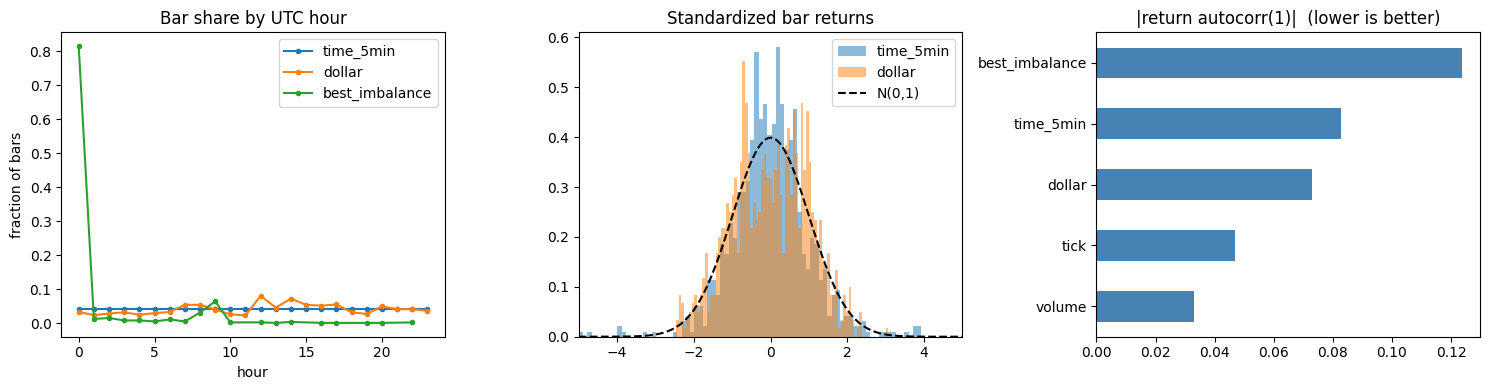

In [6]:
best_name = sweep.index[0]
it, sp, mt = (int(p.split("=")[1]) for p in best_name.split(","))
best_imb = build_bars(trades, method="dollar_imbalance", init_T=it, imb_ewma_span=sp, min_ticks=mt)
print("Best imbalance config (by composite):", best_name)

panel = {**baseline, "best_imbalance": best_imb}
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (a) bar share by UTC hour-of-day -> does sampling adapt to activity?
for name in ("time_5min", "dollar", "best_imbalance"):
    idx = pd.DatetimeIndex(panel[name].index)
    cnt = pd.Series(1, index=idx).groupby(idx.hour).sum()
    ax[0].plot(cnt.index, cnt / cnt.sum(), marker="o", ms=3, label=name)
ax[0].set(title="Bar share by UTC hour", xlabel="hour", ylabel="fraction of bars")
ax[0].legend()

# (b) standardized bar returns vs N(0,1)
for name in ("time_5min", "dollar"):
    r = np.log(panel[name]["close"]).diff().dropna()
    r = (r - r.mean()) / r.std()
    ax[1].hist(r.clip(-5, 5), bins=80, density=True, alpha=0.5, label=name)
xs = np.linspace(-5, 5, 200)
ax[1].plot(xs, np.exp(-xs**2 / 2) / np.sqrt(2 * np.pi), "k--", label="N(0,1)")
ax[1].set(title="Standardized bar returns", xlim=(-5, 5)); ax[1].legend()

# (c) |return autocorrelation| across methods
ac = pd.Series({k: abs(bar_diagnostics(v)["ret_autocorr1"]) for k, v in panel.items()})
ac.sort_values().plot.barh(ax=ax[2], color="steelblue")
ax[2].set(title="|return autocorr(1)|  (lower is better)")

plt.tight_layout()
plt.savefig(PLOTS / "01_bar_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

## 6. Findings (BTCUSDT, 2024-03-01..03)

- **Standard information bars win, clearly.** tick / volume / dollar all give near-normal returns
  (Jarque-Bera ~9-12) and |autocorr(1)| < 0.07. **Time bars are the worst**: JB = 429, excess
  kurtosis +3.5 (fat tails) and the highest `ticks_cv` (0.75) — the textbook AFML weakness.
- Among standard bars, **volume** and **tick** are marginally the most normal / least
  autocorrelated. (tick `ticks_cv` ~ 0 is trivial: bars hold a fixed tick count by construction, so
  `ticks_cv` is not a fair discriminator for them.)
- **Imbalance bars (TIB/VIB/DIB) are unstable here**: JB in the millions, `ticks_cv` ~ 11, and even
  the best-tuned config (`init_T=1000, imb_ewma_span=50`) stays far worse than plain dollar bars
  (JB 4.2e4 vs 11.5; |autocorr| 0.12 vs 0.07). They also front-load bars during the EWMA warm-up
  (the hour-0 spike in the left panel). Run bars are better than imbalance but still worse than
  standard.
- **Takeaway:** on a single, very liquid instrument (BTC perps) imbalance/run bars add instability
  without statistical benefit — consistent with the AFML view that they pay off mainly for detecting
  informed flow or on less-efficient instruments. They are a tuning rabbit hole, not free alpha.
- **Decision for the OFI study downstream: use dollar bars.** Robust, near-normal, low autocorr, and
  dollars are the natural unit for a futures microstructure study.
